# **Cuaderno 3.4 -- Funciones de activación**

El propósito de esta práctica es experimentar con diferentes funciones de activación. <br>

Trabaja a través de las celdas a continuación, ejecutando cada celda a su vez. En varios lugares verás las palabras "TO DO". Sigue las instrucciones en estos lugares y escribe código para completar las funciones. También hay preguntas intercaladas en el texto.

Contáctame en udlbookmail@gmail.com si encuentras algún error o tienes alguna sugerencia.

In [16]:
# Importa la librería de matemáticas
import numpy as np
# Importa la librería de graficación
import matplotlib.pyplot as plt

In [17]:
# Grafica la red neuronal superficial. Asumiremos que la entrada está en el rango [0,1] y la salida en [-1,1]
# Si el indicador plot_all se establece en verdadero, entonces graficaremos todas las etapas intermedias como en la Figura 3.3
def plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=False, x_data=None, y_data=None):

  # Grafica las tramas intermedias si el indicador está establecido
  if plot_all:
    fig, ax = plt.subplots(3,3)
    fig.set_size_inches(8.5, 8.5)
    fig.tight_layout(pad=3.0)
    ax[0,0].plot(x,pre_1,'r-'); ax[0,0].set_ylabel('Preactivación')
    ax[0,1].plot(x,pre_2,'b-'); ax[0,1].set_ylabel('Preactivación')
    ax[0,2].plot(x,pre_3,'g-'); ax[0,2].set_ylabel('Preactivación')
    ax[1,0].plot(x,act_1,'r-'); ax[1,0].set_ylabel('Activación')
    ax[1,1].plot(x,act_2,'b-'); ax[1,1].set_ylabel('Activación')
    ax[1,2].plot(x,act_3,'g-'); ax[1,2].set_ylabel('Activación')
    ax[2,0].plot(x,w_act_1,'r-'); ax[2,0].set_ylabel('Activación ponderada')
    ax[2,1].plot(x,w_act_2,'b-'); ax[2,1].set_ylabel('Activación ponderada')
    ax[2,2].plot(x,w_act_3,'g-'); ax[2,2].set_ylabel('Activación ponderada')

    for plot_y in range(3):
      for plot_x in range(3):
        ax[plot_y,plot_x].set_xlim([0,1]);ax[plot_x,plot_y].set_ylim([-1,1])
        ax[plot_y,plot_x].set_aspect(0.5)
      ax[2,plot_y].set_xlabel('Entrada, $x$');
    plt.show()

  fig, ax = plt.subplots()
  ax.plot(x,y)
  ax.set_xlabel('Entrada, $x$'); ax.set_ylabel('Salida, $y$')
  ax.set_xlim([0,1]);ax.set_ylim([-1,1])
  ax.set_aspect(0.5)
  if x_data is not None:
    ax.plot(x_data, y_data, 'mo')
    for i in range(len(x_data)):
      ax.plot(x_data[i], y_data[i],)
  plt.show()

In [18]:
# Define una red neuronal superficial con una entrada, una salida y tres unidades ocultas
def shallow_1_1_3(x, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31):
  pre_1 = theta_10 + theta_11 * x
  pre_2 = theta_20 + theta_21 * x
  pre_3 = theta_30 + theta_31 * x
  # Pasa estos a través de la función ReLU para calcular las activaciones como en
  # la figura 3.3 d-f
  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)

  w_act_1 = phi_1 * act_1
  w_act_2 = phi_2 * act_2
  w_act_3 = phi_3 * act_3

  y = phi_0 + w_act_1 + w_act_2 + w_act_3

  # Devuelve todo lo que hemos calculado
  return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3

In [19]:
# Define la función de Unidad Lineal Rectificada (ReLU)
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

Primero, ejecutemos la red con una función ReLU

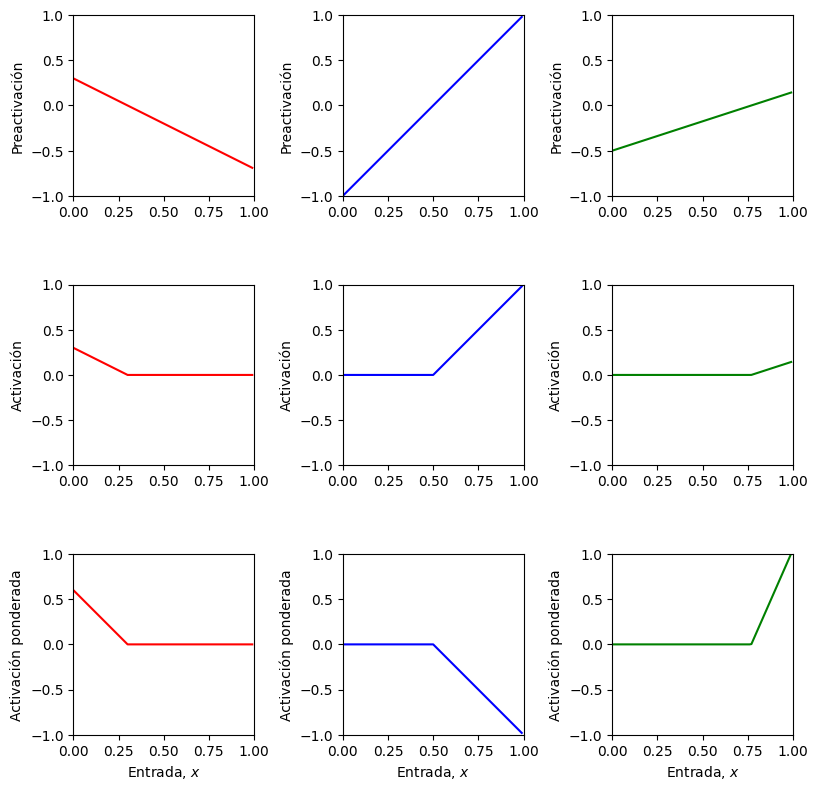

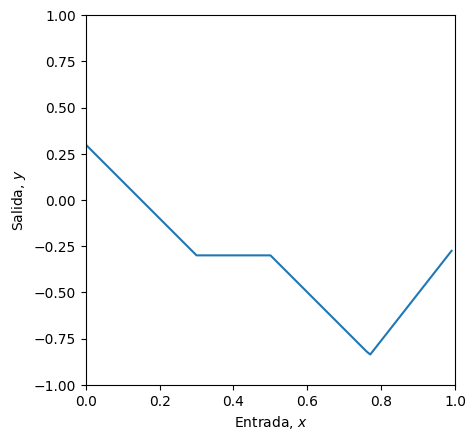

In [20]:
# Ahora definamos algunos parámetros y ejecutemos la red neuronal
theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = -0.3; phi_1 = 2.0; phi_2 = -1.0; phi_3 = 7.0

# Define un rango de valores de entrada
x = np.arange(0,1,0.01)

# Ejecutamos la red neuronal para cada uno de estos valores de entrada
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# Y luego lo graficamos
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)

# Función de activación sigmoide

La ReLU no es el único tipo de función de activación. Durante mucho tiempo, la gente usó funciones sigmoides. Una función sigmoide logística se define por la ecuación

\begin{equation}
f[z] = \frac{1}{1+\exp{[-10 z ]}}
\end{equation}

(Tenga en cuenta que el factor de 10 no es estándar, pero nos permite trazar en los mismos ejes que los ejemplos de ReLU)

In [21]:
# Define la función sigmoide
def sigmoid(preactivation):
  # TODO escribe código para implementar la función sigmoide y calcula la activación en la
  # unidad oculta a partir de la preactivación. Usa la función np.exp().
  activation = 1 / (1 + np.exp(-10 * preactivation));

  return activation

<function matplotlib.pyplot.show(close=None, block=None)>

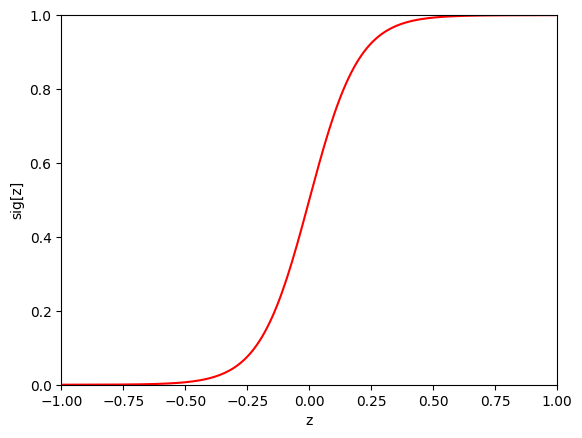

In [22]:
# Crea un array de entradas
z = np.arange(-1,1,0.01)
sig_z = sigmoid(z)

# Grafica la función sigmoide
fig, ax = plt.subplots()
ax.plot(z,sig_z,'r-')
ax.set_xlim([-1,1]);ax.set_ylim([0,1])
ax.set_xlabel('z'); ax.set_ylabel('sig[z]')
plt.show

Veamos qué sucede cuando usamos esta función de activación en una red neuronal

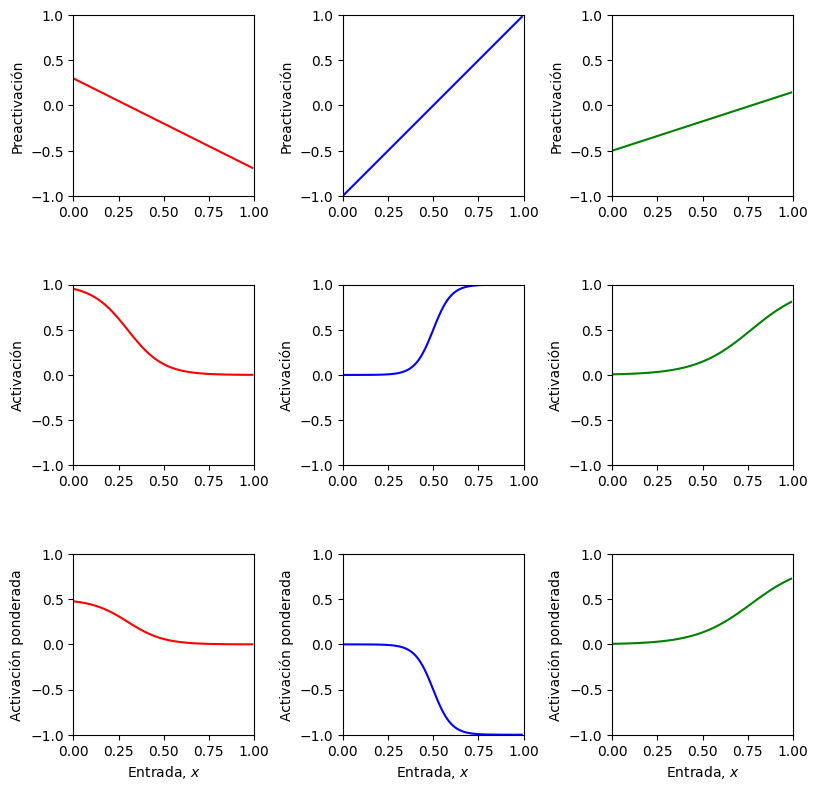

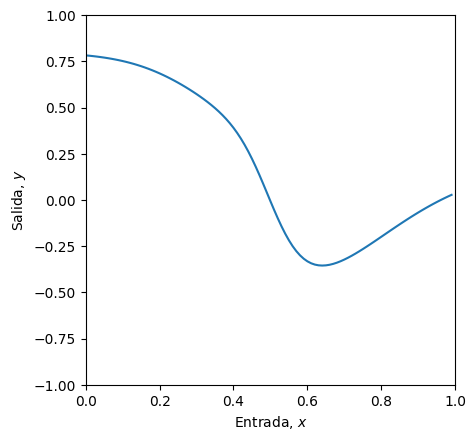

In [23]:
theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = 0.3; phi_1 = 0.5; phi_2 = -1.0; phi_3 = 0.9

# Define un rango de valores de entrada
x = np.arange(0,1,0.01)

# Ejecutamos la red neuronal para cada uno de estos valores de entrada
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, sigmoid, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# Y luego lo graficamos
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)

Probablemente notarás que esto produce curvas suaves y agradables. Entonces, ¿por qué no usamos esto? Ajá... no es obvio ahora, pero llegaremos a ello cuando aprendamos a ajustar modelos.

# Función de activación de Heaviside

La función de Heaviside se define como:

\begin{equation}
\mbox{heaviside}[z] = \begin{cases} 0 & \quad z <0 \\ 1 & \quad z\geq 0\end{cases}
\end{equation}

In [31]:
# Define la función de Heaviside
def heaviside(preactivation):
  # TODO: escribe el código para implementar la función de Heaviside y calcula la activación en la
  # unidad oculta a partir de la preactivación. Dependiendo de tu implementación, puede que necesites
  # convertir un array booleano a un array de unos y ceros. Para hacer esto, usa .astype(int)
  activation = (preactivation >= 0).astype(int)

  return activation

<function matplotlib.pyplot.show(close=None, block=None)>

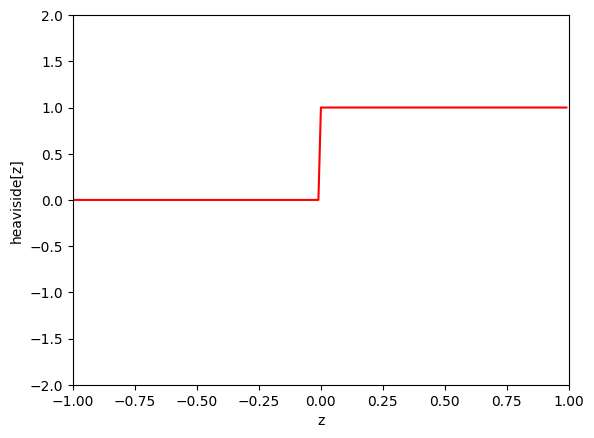

In [25]:
# Crea un array de entradas
z = np.arange(-1,1,0.01)
heav_z = heaviside(z)

# Grafica la función de Heaviside
fig, ax = plt.subplots()
ax.plot(z,heav_z,'r-')
ax.set_xlim([-1,1]);ax.set_ylim([-2,2])
ax.set_xlabel('z'); ax.set_ylabel('heaviside[z]')
plt.show

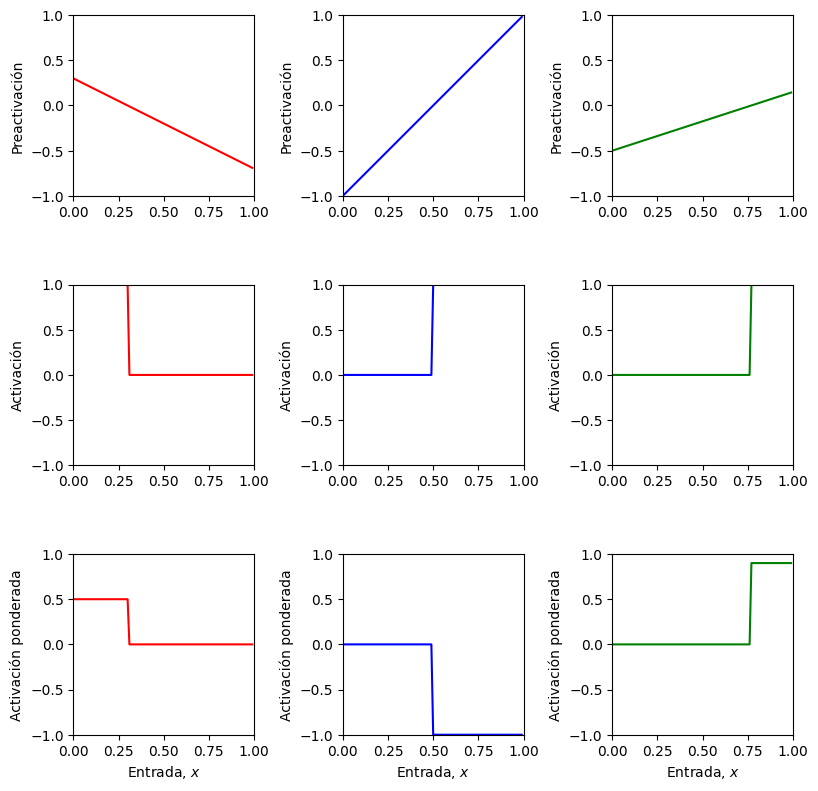

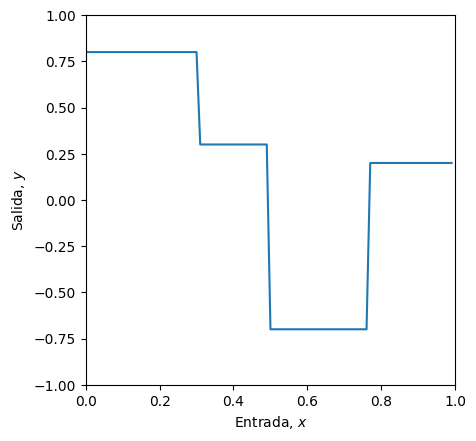

In [26]:
theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = 0.3; phi_1 = 0.5; phi_2 = -1.0; phi_3 = 0.9

# Define un rango de valores de entrada
x = np.arange(0,1,0.01)

# Ejecutamos la red neuronal para cada uno de estos valores de entrada
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, heaviside, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# Y luego lo graficamos
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)

Esto puede aproximar cualquier función, pero la salida es discontinua, y también hay razones para no usarla que descubriremos cuando aprendamos más sobre el ajuste de modelos.

# Funciones de activación lineal

Las redes neuronales no funcionan si la función de activación es lineal. Por ejemplo, considera lo que sucedería si la función de activación fuera:

\begin{equation}
\mbox{lin}[z] = a + bz
\end{equation}

In [27]:
# Define la función de activación lineal
def lin(preactivation):
  a =0
  b =1
  # Calcula la función lineal
  activation = a+b * preactivation
  # Retorna
  return activation

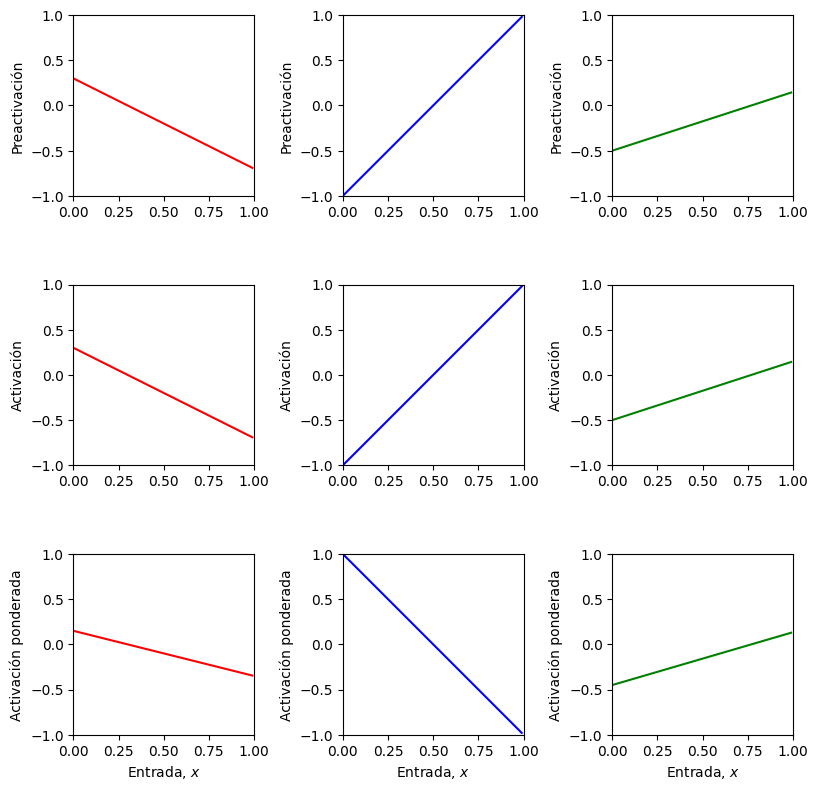

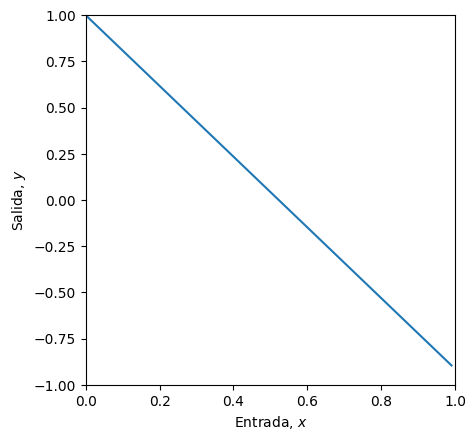

In [28]:
# TODO
# 1. La función de activación lineal anterior simplemente devuelve la entrada: (0+1*z) = z
# Antes de ejecutar el código, haz una predicción sobre cómo se verán los diez paneles del dibujo
# Ahora ejecuta el código a continuación para ver si tenías razón. ¿Qué familia de funciones puede representar esto?

# 2. ¿Qué sucede si cambias los parámetros (a,b) a diferentes valores?
# Intenta a=0.5, b=-0.4 No olvides volver a ejecutar la celda para actualizar la función

theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = 0.3; phi_1 = 0.5; phi_2 = -1.0; phi_3 = 0.9

# Define un rango de valores de entrada
x = np.arange(0,1,0.01)

# Ejecutamos la red neuronal para cada uno de estos valores de entrada
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, lin, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# Y luego lo graficamos
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)

In [29]:
def lin2(preactivation):
  a =0.5
  b =-0.4
  # Calcula la función lineal
  activation = a+b * preactivation
  # Retorna
  return activation

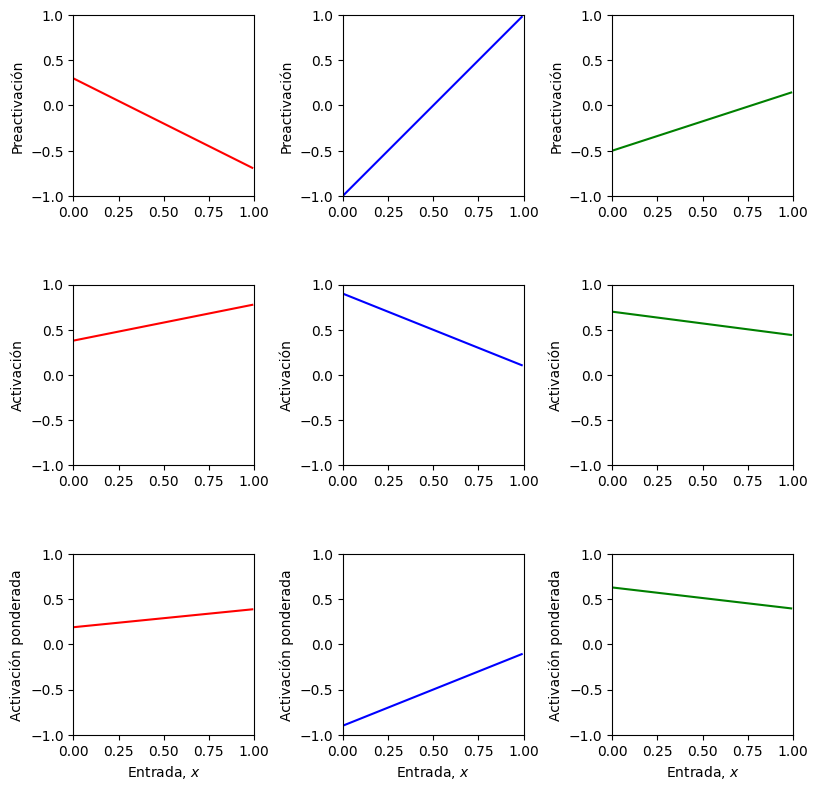

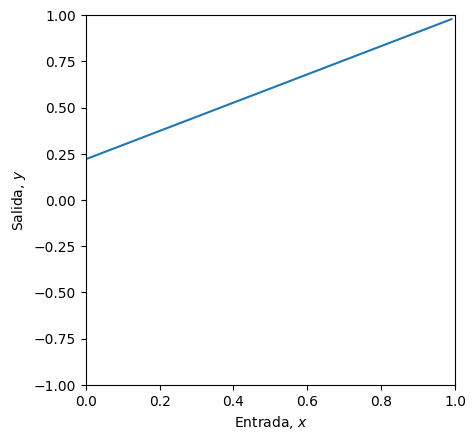

In [30]:
theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = 0.3; phi_1 = 0.5; phi_2 = -1.0; phi_3 = 0.9

# Define un rango de valores de entrada
x = np.arange(0,1,0.01)

# Ejecutamos la red neuronal para cada uno de estos valores de entrada
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, lin2, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# Y luego lo graficamos
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)